In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
import pandas as pd

df = pd.read_csv("../data/unicorn_companies.csv")

df.head()

,Company,Valuation (Billion USD),Date,Industry,Country,Founder(s)
0,ByteDance,268,December 2023 (2023-12)[17],Internet,China,"Zhang Yiming, Liang Rubo"
1,SpaceX,175,December 2023 (2023-12) [18],Aerospace,United States,Elon Musk
2,OpenAI,80-90,September 2023 (2023-09)[19],Artificial intelligence,United States,"Sam Altman, Greg Brockman, Ilya Sutskever"
3,Shein,66,May 2023 (2023-05) [13],E-commerce,China,Chris Xu
4,Stripe,50,March 2023 (2023-03) [13],Financial services,Ireland,Patrick and John Collison


In [4]:
print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nInfo:")
df.info()

print("\nDescribe:")
display(df.describe())

Shape:
(671, 6)

Columns:
Index(['Company', 'Valuation (Billion USD)', 'Date', 'Industry', 'Country',
       'Founder(s)'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 671 entries, 0 to 670
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Company                  671 non-null    object
 1   Valuation (Billion USD)  671 non-null    object
 2   Date                     671 non-null    object
 3   Industry                 607 non-null    object
 4   Country                  671 non-null    object
 5   Founder(s)               157 non-null    object
dtypes: object(6)
memory usage: 31.6+ KB

Describe:


,Company,Valuation (Billion USD),Date,Industry,Country,Founder(s)
count,671,671,671,607,671,157
unique,670,159,627,162,76,157
top,Alchemy,1+,August 2022[104],Financial technology,United States,"Zhang Yiming, Liang Rubo"
freq,2,168,13,71,217,1


In [5]:
# Missing Values

print(df.isnull().sum())

Company                      0
Valuation (Billion USD)      0
Date                         0
Industry                    64
Country                      0
Founder(s)                 514
dtype: int64


In [6]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [7]:
print(df["Country"].nunique())

76


In [8]:
df["Country"].value_counts().head(10)

Country
United States             217
China                      82
India                      67
United Kingdom             29
France                     29
Israel                     20
Canada                     19
South Korea                18
Germany                    15
Israel / United States     13
Name: count, dtype: int64

In [10]:
df["Industry"].value_counts().head(10)

Industry
Financial technology       71
Software                   52
E-commerce                 30
Cybersecurity              23
Artificial intelligence    21
Financial services         18
Technology                 17
Marketplace                16
Cryptocurrency             15
Healthcare                 15
Name: count, dtype: int64

In [11]:
df["Valuation (Billion USD)"].unique()[:20]

array(['268', '175', '80-90', '66', '50', '43', '20-30', '31.5', '30',
       '27', '25', '22', '20', '17.7', '17.5', 'Undisclosed', '16.5',
       '15.5', '15', '14'], dtype=object)

In [12]:
# Copy column

df["Valuation_Clean"] = df["Valuation (Billion USD)"]

# Range values ka average lo

def clean_valuation(x):
    x = str(x)

    if "-" in x:
        a, b = x.split("-")
        return (float(a) + float(b)) / 2

    elif "+" in x:
        return float(x.replace("+", ""))

    elif x == "Undisclosed":
        return None

    else:
        return float(x)

df["Valuation_Clean"] = df["Valuation_Clean"].apply(clean_valuation)

df[["Valuation (Billion USD)", "Valuation_Clean"]].head(10)

,Valuation (Billion USD),Valuation_Clean
0,268,268.0
1,175,175.0
2,80-90,85.0
3,66,66.0
4,50,50.0
5,43,43.0
6,20-30,25.0
7,31.5,31.5
8,30,30.0
9,27,27.0


In [13]:
df["Valuation_Clean"].describe()

count    670.000000
mean       4.255970
std       13.573639
min        1.000000
25%        1.000000
50%        1.800000
75%        3.675000
max      268.000000
Name: Valuation_Clean, dtype: float64

In [14]:
df["Valuation_Clean"].isnull().sum()

np.int64(1)

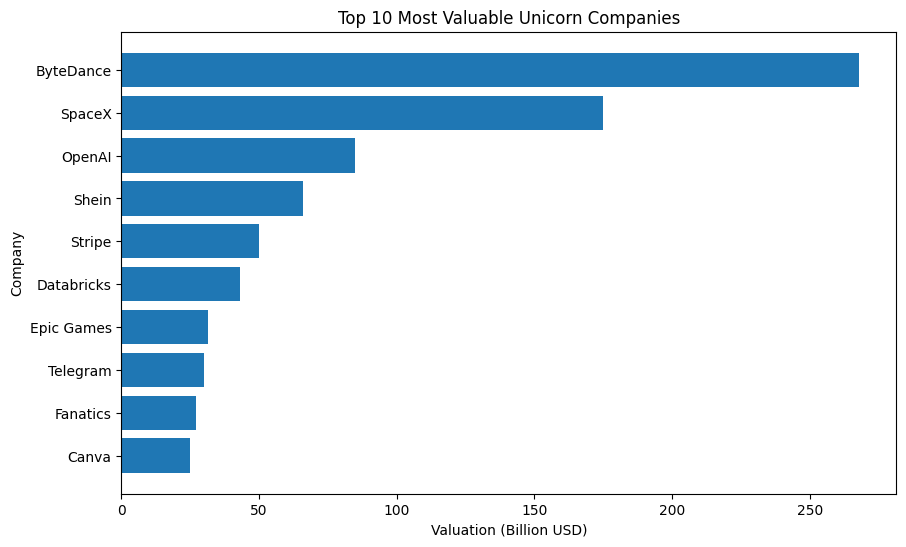

In [15]:
import matplotlib.pyplot as plt

top10 = df.sort_values(
    by="Valuation_Clean",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Company"],
    top10["Valuation_Clean"]
)

plt.xlabel("Valuation (Billion USD)")
plt.ylabel("Company")
plt.title("Top 10 Most Valuable Unicorn Companies")

plt.gca().invert_yaxis()

plt.show()

In [16]:
df.isnull().sum()

Company                      0
Valuation (Billion USD)      0
Date                         0
Industry                    64
Country                      0
Founder(s)                 514
Valuation_Clean              1
dtype: int64

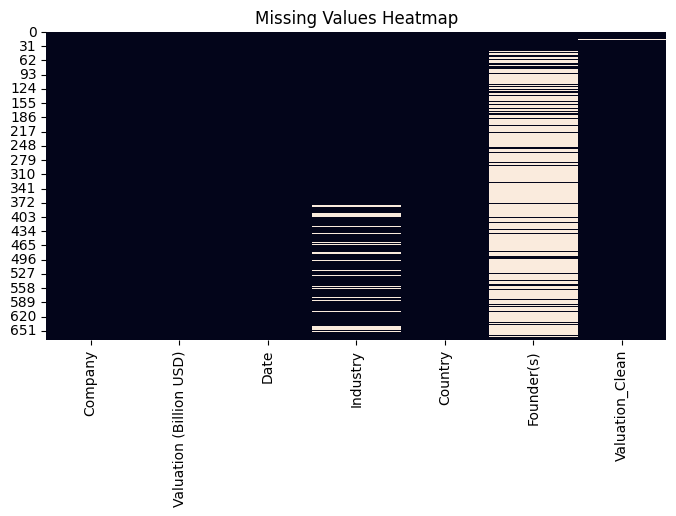

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [18]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


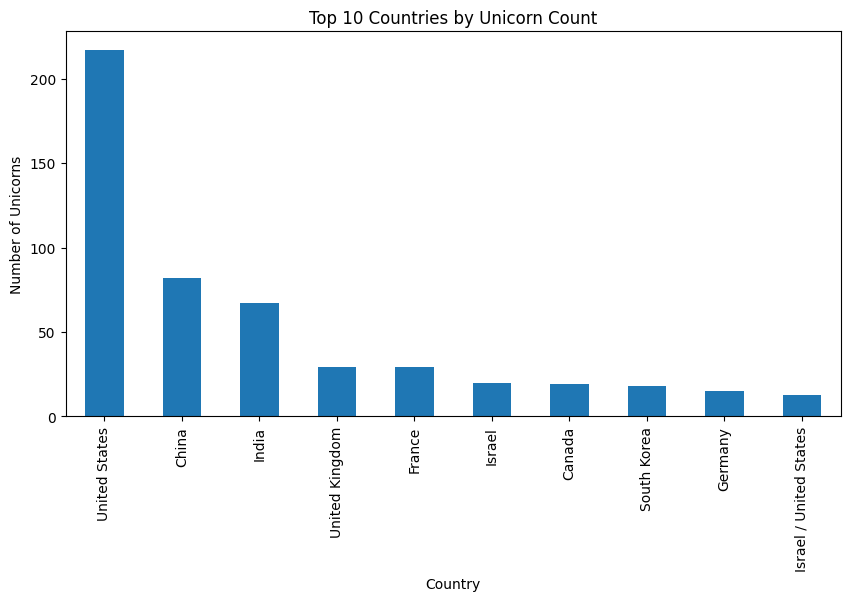

In [19]:
country_counts = df["Country"].value_counts().head(10)

plt.figure(figsize=(10,5))
country_counts.plot(kind="bar")
plt.title("Top 10 Countries by Unicorn Count")
plt.ylabel("Number of Unicorns")
plt.show()

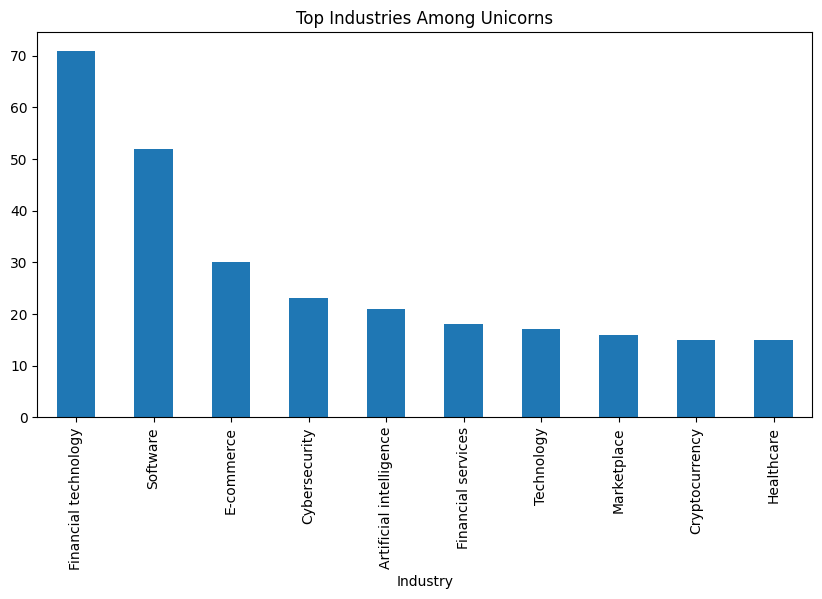

In [20]:
industry_counts = df["Industry"].value_counts().head(10)

plt.figure(figsize=(10,5))
industry_counts.plot(kind="bar")
plt.title("Top Industries Among Unicorns")
plt.show()

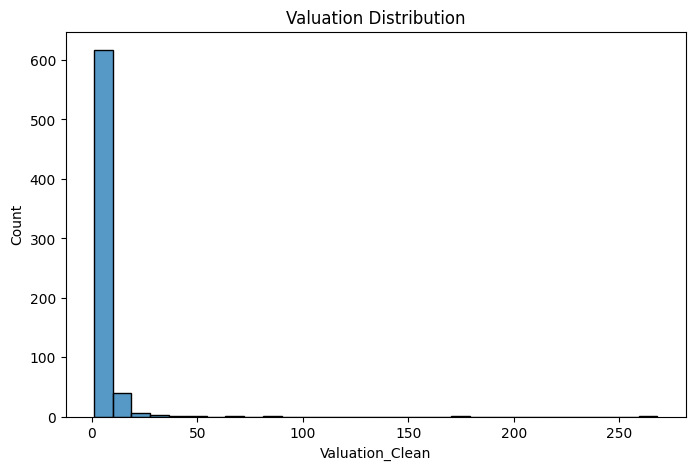

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df["Valuation_Clean"], bins=30)
plt.title("Valuation Distribution")
plt.show()

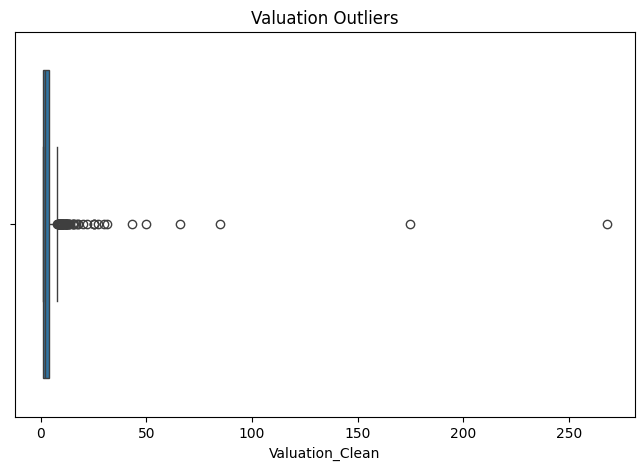

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Valuation_Clean"])
plt.title("Valuation Outliers")
plt.show()

In [23]:
df["Date"].head()

0     December 2023 (2023-12)[17]
1    December 2023 (2023-12) [18]
2    September 2023 (2023-09)[19]
3         May 2023 (2023-05) [13]
4       March 2023 (2023-03) [13]
Name: Date, dtype: object

In [25]:
df["Year"] = df["Date"].str.extract(r'(\d{4})')

In [26]:
df["Year"].value_counts().sort_index()

Year
2012      2
2013      1
2014      4
2015     16
2016     21
2017     29
2018     41
2019     48
2020     53
2021    358
2022     75
2023     23
Name: count, dtype: int64

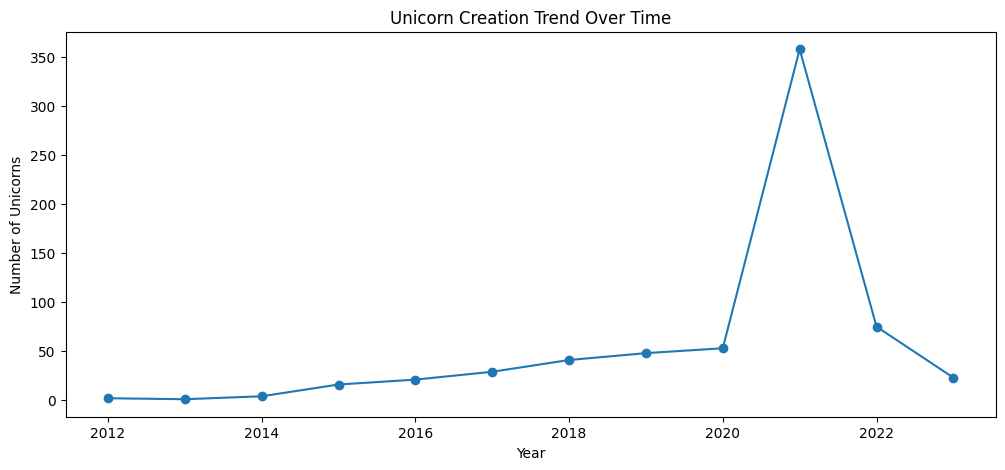

In [27]:
year_counts = df["Year"].value_counts().sort_index()

plt.figure(figsize=(12,5))
year_counts.plot(marker="o")
plt.title("Unicorn Creation Trend Over Time")
plt.ylabel("Number of Unicorns")
plt.show()

Key Findings

1. United States has the highest number of unicorn companies.

2. Financial Technology and AI are dominant industries.

3. Unicorn valuations are highly skewed.

4. Several valuation outliers exist.

5. Founder information is missing for a large portion of records.

6. Unicorn creation accelerated significantly after 2020.


In [28]:
country_industry = pd.crosstab(
    df["Country"],
    df["Industry"]
)

country_industry.head()

Industry,3D printing,Accounting software,Advertising technology,Aerospace,"Agriculture, E-commerce",Analytics,Application security,Aquaculture,Architecture,Artificial Intelligence,...,VPN service,Venture capital,Video games,Video messaging,Virtual event,Waste management,Wearable technology,Web development,WebOps,Workforce management
Country,,,,,,,,,,,,,,,,,,,,,
Argentina,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Argentina / United States,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Armenia / United States,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Australia,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Australia / Hong Kong,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


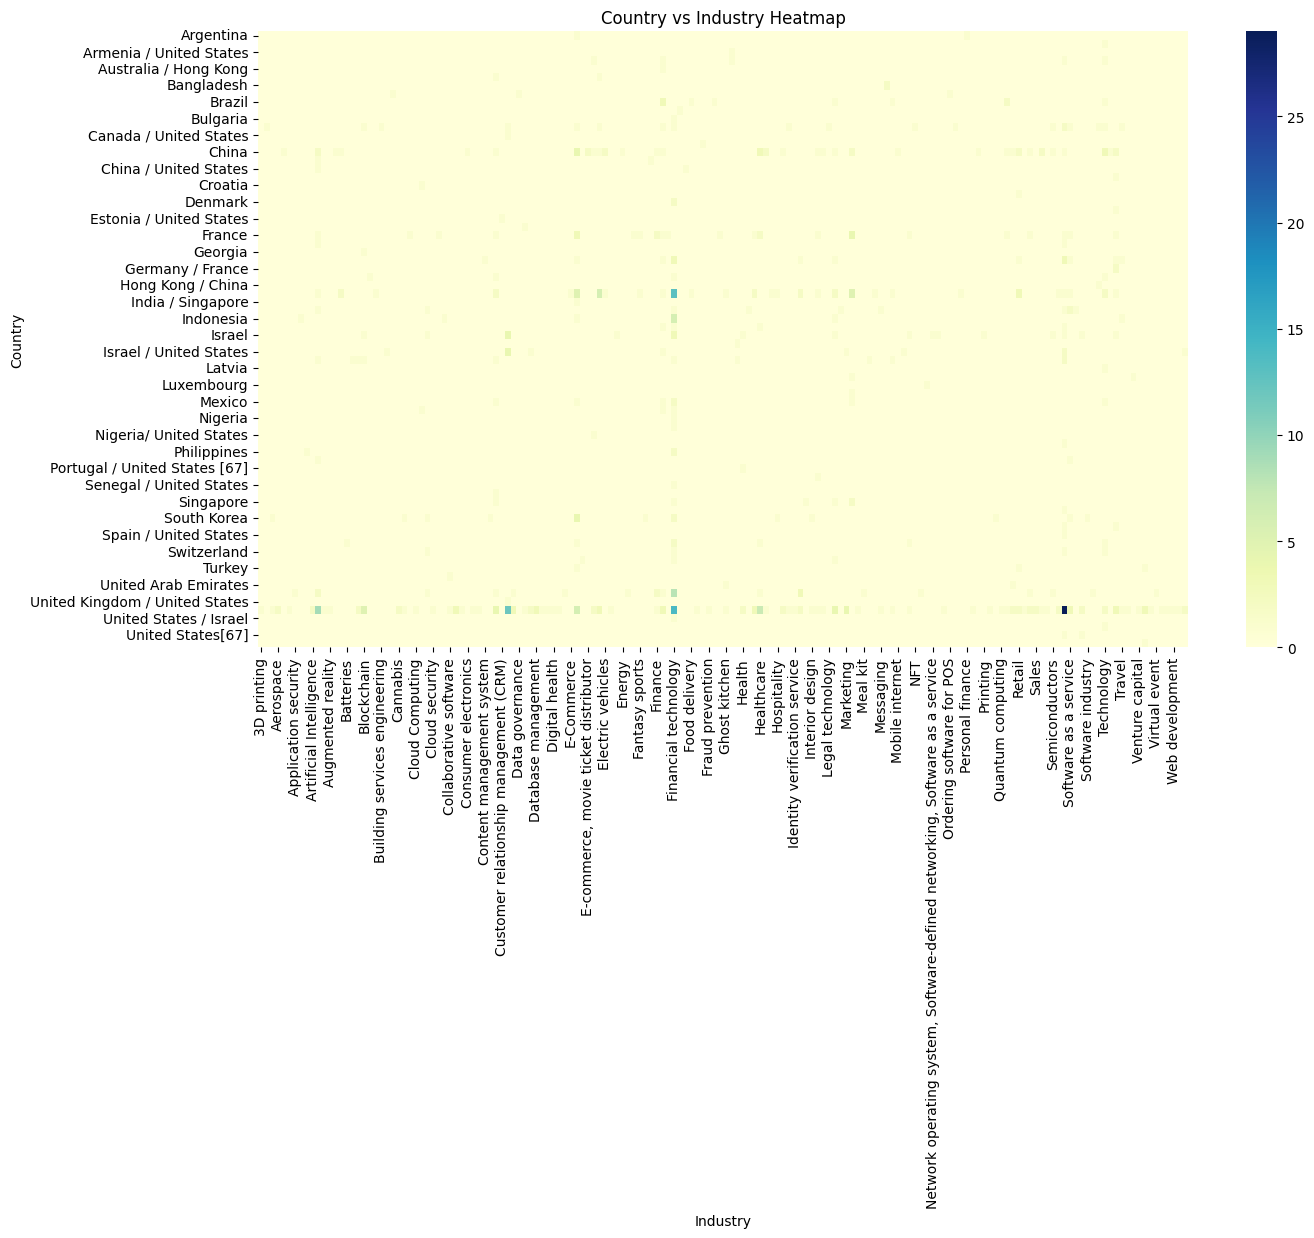

In [29]:
plt.figure(figsize=(15,8))

sns.heatmap(
    country_industry,
    cmap="YlGnBu"
)

plt.title("Country vs Industry Heatmap")
plt.show()

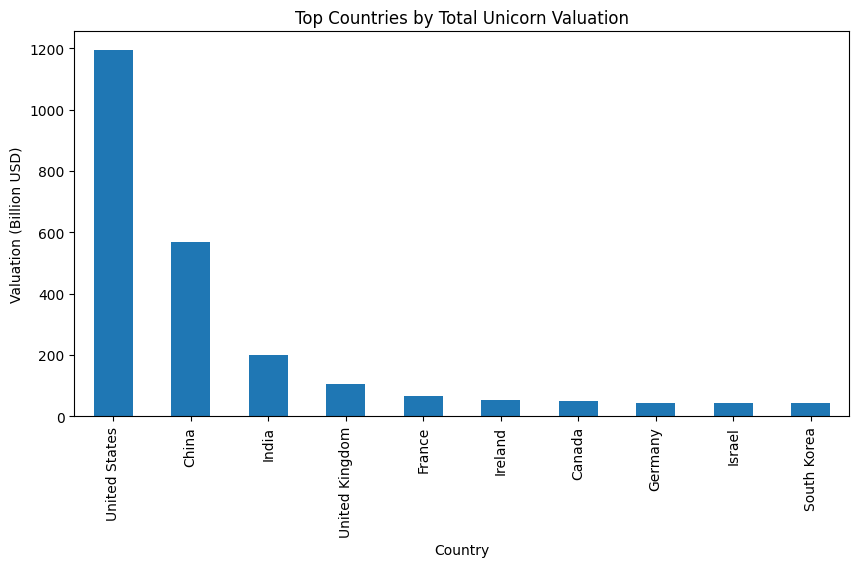

In [30]:
country_valuation = df.groupby(
    "Country"
)["Valuation_Clean"].sum().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

country_valuation.plot(kind="bar")

plt.title("Top Countries by Total Unicorn Valuation")
plt.ylabel("Valuation (Billion USD)")
plt.show()

United States contributes the highest total unicorn valuation globally.
China follows as the second largest unicorn ecosystem.

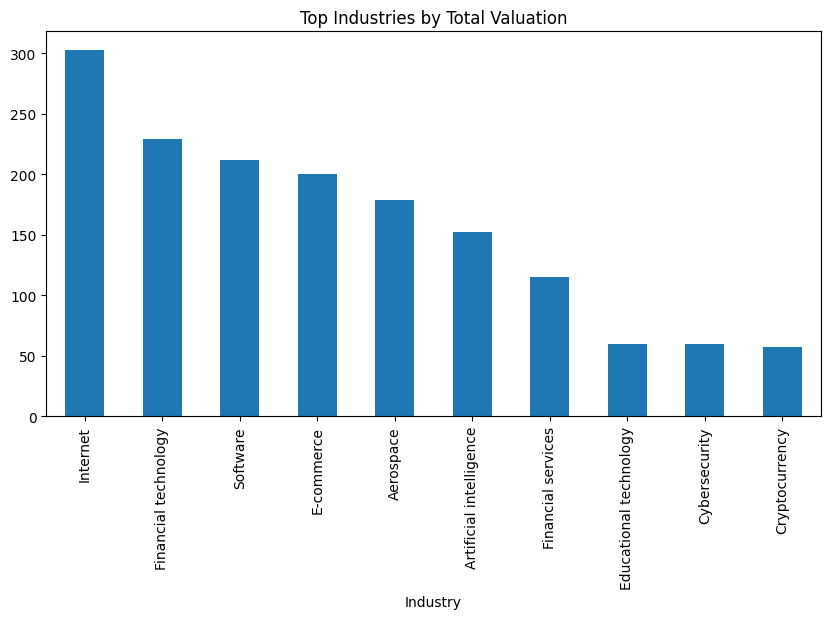

In [31]:
industry_valuation = df.groupby(
    "Industry"
)["Valuation_Clean"].sum().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

industry_valuation.plot(kind="bar")

plt.title("Top Industries by Total Valuation")
plt.show()

In [32]:
df["Year"] = pd.to_numeric(
    df["Year"],
    errors="coerce"
)

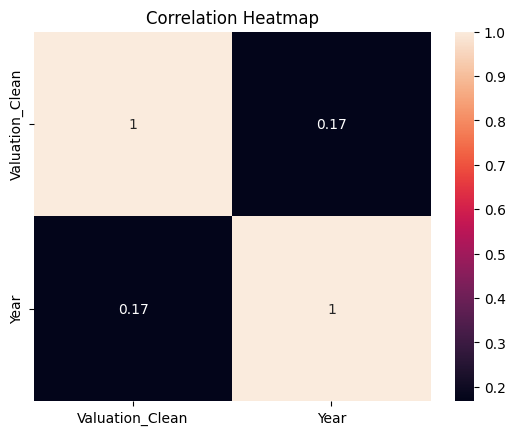

In [33]:
corr = df[[
    "Valuation_Clean",
    "Year"
]].corr()

sns.heatmap(
    corr,
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()

Recommendations

1. Investors should focus on AI and FinTech sectors due to strong unicorn presence.

2. United States and China remain the strongest startup ecosystems.

3. Missing founder information should be improved for better ecosystem analysis.

4. High valuation outliers indicate concentrated market power among a few firms.

5. Emerging countries show opportunities for future unicorn growth.

Executive Summary

This analysis examined 671 unicorn companies across multiple countries and industries.

Key Findings:

• United States leads the global unicorn ecosystem.

• Financial Technology and Artificial Intelligence dominate the market.

• Unicorn valuations are highly skewed due to a small number of extremely valuable firms.

• Significant missing data exists in founder information.

• Unicorn creation accelerated rapidly after 2020.

The analysis provides insights for investors, entrepreneurs, and policymakers regarding global startup trends.